In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
sys.path.append('../../')
import numpy as np
import torch
from model.MinAggGNN import MinAggGNN
import matplotlib.pyplot as plt

device = torch.device('cuda')
L = 2
m = 2
epochs = 20000
eta = 0.001
seed = 0

model = MinAggGNN(1, 8, L, 1, edge_dim = 1)
state_dict = torch.load(f'../model_progress/bellman_ford/seed_{seed}/model_final.pt')
model.load_state_dict(state_dict)
model.eval()
model.to(device)

c:\Users\heje197\AppData\Local\miniconda3\envs\minar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MinAggGNN(1, 1, num_layers=2)

In [2]:
from MINAR.ComputationGraph import ComputationGraph, Circuit
from model.CustomLosses import MultiplicativeLoss
import torch_geometric as pyg
import networkx as nx

G = ComputationGraph(model)
G.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
              'input_self' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
G.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
G.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
G.number_of_edges()

18240

In [3]:
test_data = torch.load('../data/test_data.pt', map_location=device, weights_only=False)
test_loader = pyg.loader.DataLoader(test_data, batch_size = len(test_data))
criterion = MultiplicativeLoss()
mse_criterion = torch.nn.MSELoss()
num_reachable_test_nodes = sum([data.reachable.sum() for data in test_loader])

In [ ]:
corrupted_data = torch.load('../data/test_data.pt', map_location=device, weights_only=False)
for data_corr in corrupted_data:
    data_corr.x = torch.zeros_like(data_corr.x, device=device)
    data_corr.edge_attr = torch.zeros_like(data_corr.edge_attr, device=device)

In [6]:
from tqdm import tqdm
def find_best_K(G, model, test_loader, which='EAP-IG', max_K=50, eps=1e-3, verbose=True):
    best_loss = np.inf
    best_K = -1
    Ks = range(max_K+1)
    if verbose:
        Ks = tqdm(Ks)
    for K in Ks:
        C_tmp = Circuit(model, G, K=K, key=which)
        total_loss = 0.0
        for data in test_loader:
            out = C_tmp.forward(data)
            total_loss += float(criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
        if total_loss < best_loss - eps:
            best_loss = total_loss
            best_K = K
            if verbose:
                Ks.set_description(f'Best K: {best_K}, Loss: {best_loss:.4f}')
    return best_K

In [25]:
checkpoints = torch.load(f'../model_progress/bellman_ford/seed_{seed}/model_checkpoints.pt')
idx = 2
check_epochs = [1000, 2000, 3000]
check_epoch = check_epochs[idx]
checkpoint_idx = check_epoch // 100 - 1
checkpoint_mid = checkpoints[checkpoint_idx]

model.load_state_dict(checkpoint_mid)
model.eval()

G_mid = ComputationGraph(model)
G_mid.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
              'input_self' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
G_mid.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
G_mid.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
G_mid.calculate_scores(test_data, corrupted_data, mse_criterion, which = 'EAP-IG', steps=20)

In [26]:
K = find_best_K(G_mid, model, test_loader, which='EAP-IG')
print(f'Best K: {K}')
C_mid = Circuit(model, G_mid, K=K, key='EAP-IG')
print(C_mid.number_of_edges())
for data in test_loader:
    out = C_mid.forward(data)
    mul_circuit_loss = float(criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    mse_circuit_loss = float(mse_criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    print(f'Circuit Test Loss: {mul_circuit_loss:.4f}')
    print(f'Circuit Test MSE Loss: {mse_circuit_loss:.4f}')

Best K: 2, Loss: 0.0543: 100%|██████████| 51/51 [01:35<00:00,  1.87s/it]  


Best K: 2
10
Circuit Test Loss: 0.0543
Circuit Test MSE Loss: 0.0000


In [27]:
edge_weights = []
for _,_,data in G.edges(data=True):
    w = data.get('weight', None)
    edge_weights.extend(np.atleast_1d(w).ravel().tolist())
abs_vmax = max(abs(np.array(edge_weights)))

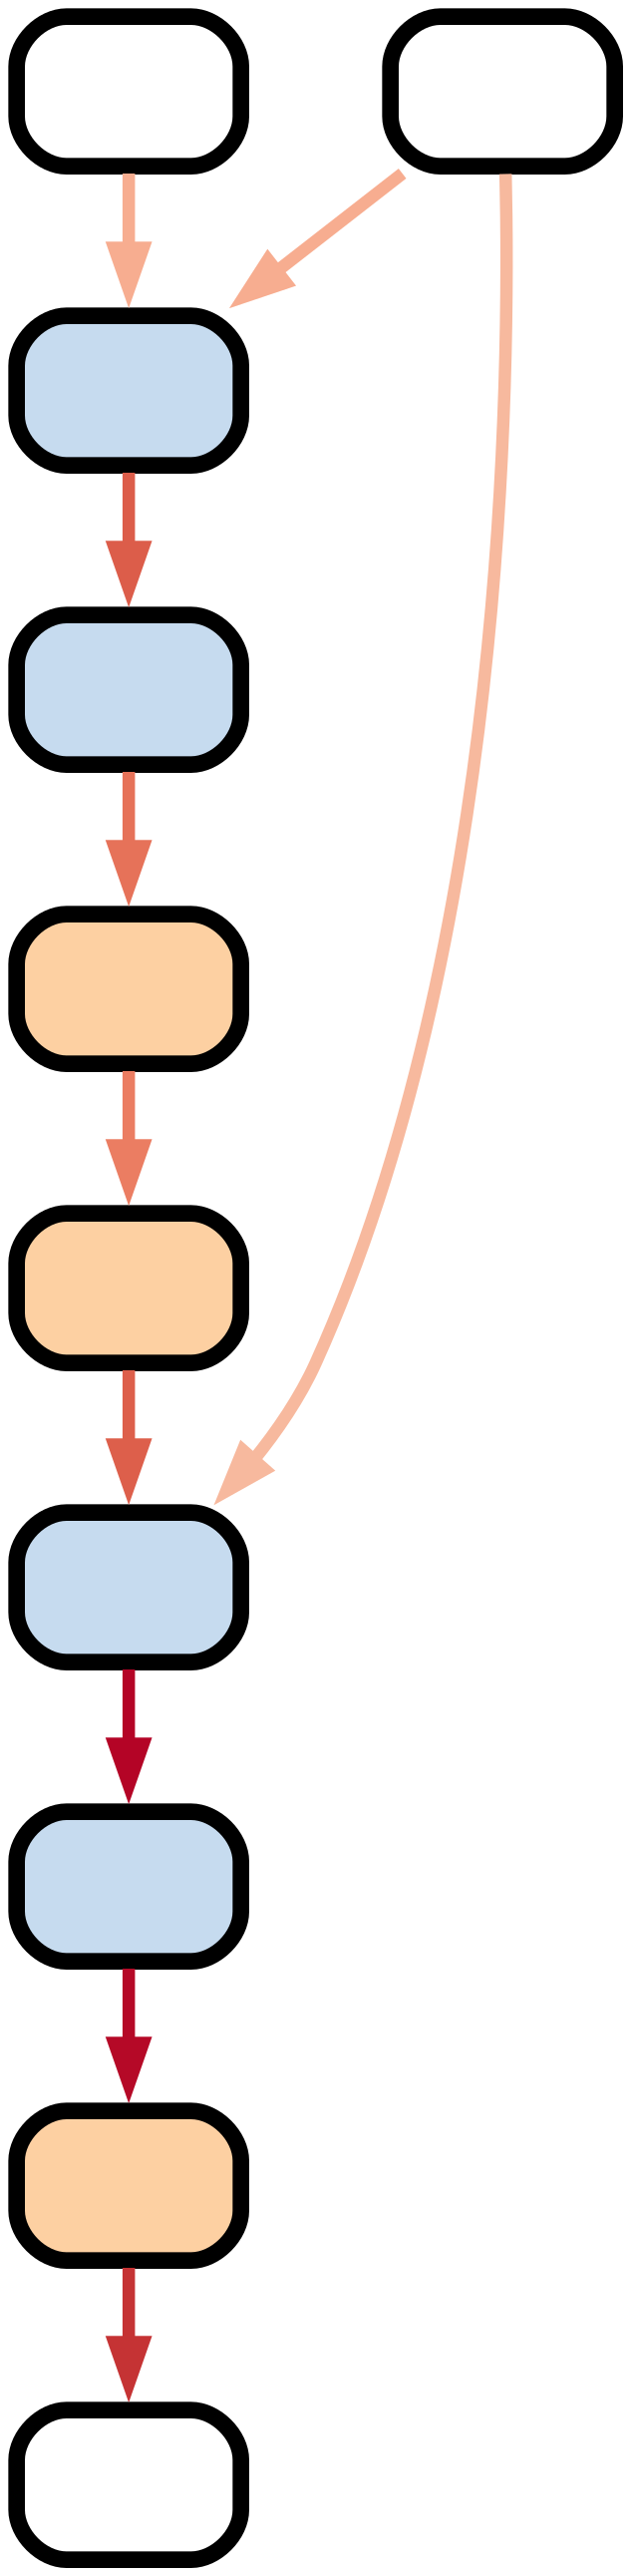

In [28]:
from matplotlib import colors
from IPython.display import display
from PIL import Image
nx.relabel_nodes(C_mid, {'edge_attr' : 'edge_weight',
                     'input.0' : 'x',
                     'convs.1.up_mlp.lins.1.0' : 'output'},
                     copy=False)
C_mid_pydot = nx.nx_agraph.to_agraph(C_mid)
C_mid_pydot.node_attr['shape'] = 'box'
C_mid_pydot.node_attr['style'] = 'rounded, filled'

layer_colors = ['white', '#c6dbef', '#c6dbef', '#fdd0a2', '#fdd0a2', '#c6dbef', '#c6dbef', '#fdd0a2', 'white']
node_colors = {node : layer_colors[layer] for node, layer in nx.get_node_attributes(C_mid, 'layer').items()}
for v in C_mid_pydot.nodes():
    node = C_mid_pydot.get_node(v)
    node.attr['fillcolor'] = node_colors[node]
    node.attr['style'] = 'rounded, filled, bold'
    node.attr['penwidth'] = 4.0

edge_cmap=plt.cm.coolwarm
_, circuit_edge_weights = zip(*nx.get_edge_attributes(C_mid,'weight').items())
normalized_weights = {edge : weight / (2*abs_vmax) + 0.5 for edge, weight in nx.get_edge_attributes(C_mid,'weight').items()}
for u,v in C_mid_pydot.edges():
    edge = C_mid_pydot.get_edge(u,v)
    edge.attr['color'] = colors.to_hex(edge_cmap(normalized_weights[edge]))
    edge.attr["penwidth"] = 3.0

spine = ['x',
         'convs.0.agg_mlp.lins.0.58',
         'convs.0.agg_mlp.lins.1.17',
         'convs.0.up_mlp.lins.0.14',
         'convs.0.up_mlp.lins.1.2',
         'convs.1.agg_mlp.lins.0.5',
         'convs.1.agg_mlp.lins.1.55',
         'convs.1.up_mlp.lins.0.5',
         'output']
for i in range(len(spine)-1):
    edge = C_mid_pydot.get_edge(spine[i],spine[i+1])
    edge.attr['weight'] = 100

for node in C_mid_pydot.nodes():
    node.attr['label'] = ""

C_mid_pydot.graph_attr['nodesep'] = '.5'
C_mid_pydot.graph_attr['splines'] = 'true'
C_mid_pydot.graph_attr['dpi'] = 300
C_mid_pydot.draw(f"../images/poster_bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.pdf", prog="dot")
C_mid_pydot.draw(f"../images/poster_bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.png", prog="dot")
display(Image.open(f"../images/poster_bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.png"))